<a href="https://colab.research.google.com/github/humamibrahim-cyber/heritage-tourism-ai/blob/main/notebooks/02_recommendation_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 — Tourism Recommendation Engine

**Preserving Heritage: Enhancing Tourism with AI** · AIML Capstone 2

Understanding tourists and their expectations is critical for marketing
Indonesian destinations. This notebook performs exploratory data analysis on
visitor ratings across five major Indonesian cities, then builds a
**collaborative filtering** recommender that answers the agency's question:
*given the place a tourist is at now, where should they go next?*

### Datasets

| File | Contents |
|---|---|
| `user.csv` | User_Id, Location, Age — visitor demographics |
| `tourism_with_id.xlsx` | Place_Id, Place_Name, Description, Category, City, Price, Rating, Time_Minutes, Coordinate, Lat, Long |
| `tourism_rating.csv` | User_Id, Place_Id, Place_Ratings — the interaction matrix |

> The brief refers to `tourism_with_id.csv`; the supplied file is an `.xlsx`.
> The loader accepts either.

### How this notebook maps to the brief

| Brief task | Where |
|---|---|
| 1. Import datasets; check missing values and duplicates; remove anomalies | §2–3 |
| 2. Explore the rating user group — age distribution, where tourists come from | §4 |
| 3. Categories of tourist spots; what each location is famous for; best city for a nature enthusiast | §5 |
| 4. Combine places with user ratings; most-loved spots and city; most-liked category | §6 |
| 5. Build a collaborative filtering recommender; recommend places from the current place name | §8–10 |

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL  = "https://github.com/humamibrahim-cyber/heritage-tourism-ai.git"
REPO_NAME = "heritage-tourism-ai"

if IN_COLAB:
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", REPO_URL], check=False)
    if Path(REPO_NAME).exists():
        sys.path.insert(0, str(Path(REPO_NAME).resolve()))
else:
    sys.path.insert(0, str(Path.cwd().parent))

# Expected Drive layout:
#   MyDrive/heritage-data/tourism/{user.csv, tourism_rating.csv, tourism_with_id.xlsx}
DATA_ROOT = Path("/content/data") if IN_COLAB else Path.cwd().parent / "data"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    src_dir = Path("/content/drive/MyDrive/heritage-data/tourism")
    assert src_dir.exists(), f"Not found: {src_dir}\nUpload the three Part 2 files there."
    (DATA_ROOT / "tourism").mkdir(parents=True, exist_ok=True)
    subprocess.run(f'cp "{src_dir}"/* "{DATA_ROOT}/tourism/"', shell=True, check=True)

os.environ["HERITAGE_DATA_ROOT"] = str(DATA_ROOT)
print("DATA_ROOT:", DATA_ROOT)

Mounted at /content/drive
DATA_ROOT: /content/data


In [2]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.config as config
importlib.reload(config)

from src.config import RecoConfig
from src.data import tourism_data as td
from src.evaluation import ranking as R
from src.models.item_cf import ItemBasedCF, PopularityBaseline
from src.viz.plots import ACCENT, CONTRAST, PALETTE, plot_bar, use_house_style

use_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

cfg = RecoConfig(tourism_dir=DATA_ROOT / "tourism", top_k=10, embedding_dim=32)
print("tourism dir exists:", cfg.tourism_dir.exists())

tourism dir exists: True


## 2. Import, inspect and clean — *brief task 1*

The loader normalises column names to a canonical lower-case form and drops the
two trailing unnamed columns this dataset is known to ship with, so nothing
downstream depends on the exact capitalisation in the source file.

In [3]:
raw = td.load_raw(cfg)
for name, df in raw.items():
    print(f"{name:8} shape={df.shape}")
    display(df.head(3))

[places] dropped empty/unnamed columns: ['Unnamed: 11', 'Unnamed: 12']
places   shape=(437, 11)


,place_id,place_name,description,category,city,price,rating,time_minutes,coordinate,lat,long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538


ratings  shape=(10000, 3)


,user_id,place_id,place_ratings
0,1,179,3
1,1,344,2
2,1,5,5


users    shape=(300, 3)


,user_id,location,age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21
2,3,"Cirebon, Jawa Barat",23


In [4]:
# Task 1.I - missing values, duplicates, dtypes
for name in ["places", "ratings", "users"]:
    display(td.inspect(raw[name], name))


=== places === shape=(437, 11)  duplicated_rows=0


,dtype,n_missing,pct_missing,n_unique,example
place_id,int64,0,0.00,437,1
place_name,object,0,0.00,437,Monumen Nasional
description,object,0,0.00,437,Monumen Nasional atau yang populer disingkat d...
category,object,0,0.00,6,Budaya
city,object,0,0.00,5,Jakarta
price,int64,0,0.00,50,20000
rating,float64,0,0.00,14,4.6
time_minutes,float64,232,53.09,15,15.0
coordinate,object,0,0.00,437,"{'lat': -6.1753924, 'lng': 106.8271528}"
lat,float64,0,0.00,437,-6.175392



=== ratings === shape=(10000, 3)  duplicated_rows=79


,dtype,n_missing,pct_missing,n_unique,example
user_id,int64,0,0.0,300,1
place_id,int64,0,0.0,437,179
place_ratings,int64,0,0.0,5,3



=== users === shape=(300, 3)  duplicated_rows=0


,dtype,n_missing,pct_missing,n_unique,example
user_id,int64,0,0.0,300,1
location,object,0,0.0,28,"Semarang, Jawa Tengah"
age,int64,0,0.0,23,20


**What the inspection shows.** `time_minutes` is roughly half missing. We
deliberately leave it as `NaN` rather than filling it with the column mean:
inventing tour durations for 200+ attractions would put fabricated numbers into
the EDA and any figure computed from them would be meaningless. It is simply
excluded from analyses that need it.

In [5]:
# Task 1.II - remove duplicates and anomalies
data = td.clean(raw, cfg)
places, ratings, users = data["places"], data["ratings"], data["users"]

Cleaning summary
  - ratings: removed 403 duplicate (user, place) pairs
  - ratings: removed 0 out-of-range ratings
  - users: removed 0 rows with impossible ages
  - places: removed 0 duplicate place_ids
  - ratings: removed 0 orphan rows

Final shapes  places=(437, 11)  ratings=(9597, 3)  users=(300, 5)
Rating matrix density: 7.32% (sparsity 92.68%)


## 3. Descriptive statistics, outliers and normalisation

Cleaning removes what is *invalid*. This section characterises what remains:
how each variable is distributed, which values are extreme, whether the missing
data is missing for a reason, and what scaling any downstream model needs.

The governing principle: **an outlier is not automatically an error.** Some of
what follows is corrupt data that must be fixed; some is real and must be kept.
Deleting everything a rule flags would be data destruction.

In [6]:
from src.data import eda

# --- 3.1 Distribution statistics -------------------------------------------
# describe() omits skew and kurtosis, which are exactly what tell you whether
# the mean is meaningful and whether a transform is needed.
print("PLACES — numeric")
display(eda.numeric_summary(places, ["price", "rating", "time_minutes", "lat", "long"]))

print("\nUSERS — numeric")
display(eda.numeric_summary(users, ["age"]))

print("\nCategorical")
display(eda.categorical_summary(places, ["category", "city"]))

PLACES — numeric


,n,n_missing,pct_missing,n_zero,mean,std,min,q1,median,q3,max,iqr,cv,skew,kurtosis
column,,,,,,,,,,,,,,,
price,437,0,0.00,137,24652.174,66446.375,0.000,0.000,5000.000,20000.000,900000.000,20000.000,2.695,7.344,76.961
rating,437,0,0.00,0,4.443,0.209,3.400,4.300,4.500,4.600,5.000,0.300,0.047,-0.626,1.583
time_minutes,205,232,53.09,0,82.610,52.872,10.000,45.000,60.000,120.000,360.000,75.000,0.640,1.593,4.257
lat,437,0,0.00,0,-7.095,0.727,-8.198,-7.750,-7.021,-6.829,1.079,0.920,-0.102,3.254,34.795
long,437,0,0.00,0,109.160,1.963,103.931,107.578,110.237,110.432,112.822,2.854,0.018,0.241,-1.106



USERS — numeric


,n,n_missing,pct_missing,n_zero,mean,std,min,q1,median,q3,max,iqr,cv,skew,kurtosis
column,,,,,,,,,,,,,,,
age,300,0,0.0,0,28.7,6.394,18.0,24.0,29.0,34.0,40.0,10.0,0.223,0.008,-1.06



Categorical


,n_levels,n_missing,mode,mode_count,mode_share_%,normalised_entropy
column,,,,,,
category,6,0,Taman Hiburan,135,30.9,0.860
city,5,0,Yogyakarta,126,28.8,0.954


In [7]:
# Interaction counts - are some users or places over-represented?
per_user = ratings.groupby("user_id").size().rename("n_ratings").to_frame()
per_place = ratings.groupby("place_id").size().rename("n_ratings").to_frame()
print("Ratings per user"); display(eda.numeric_summary(per_user))
print("Ratings per place"); display(eda.numeric_summary(per_place))
print(f"Places with fewer than 5 ratings: {(per_place['n_ratings'] < 5).sum()}")

Ratings per user


,n,n_missing,pct_missing,n_zero,mean,std,min,q1,median,q3,max,iqr,cv,skew,kurtosis
column,,,,,,,,,,,,,,,
n_ratings,300,0,0.0,0,31.99,5.308,21.0,28.0,32.0,36.0,53.0,8.0,0.166,0.338,0.235


Ratings per place


,n,n_missing,pct_missing,n_zero,mean,std,min,q1,median,q3,max,iqr,cv,skew,kurtosis
column,,,,,,,,,,,,,,,
n_ratings,437,0,0.0,0,21.961,4.503,12.0,19.0,22.0,25.0,39.0,6.0,0.205,0.364,-0.047


Places with fewer than 5 ratings: 0


In [8]:
# --- 3.2 Outlier detection, three ways -------------------------------------
# Where the methods disagree sharply, the column is skewed and the robust
# (MAD) verdict is the one to trust: z-scores are computed using a standard
# deviation that the outliers themselves inflated.
display(eda.outlier_report(places, ["price", "rating", "time_minutes"]))

,n_valid,n_iqr,pct_iqr,n_zscore,pct_zscore,n_mad,pct_mad,max
column,,,,,,,,
price,437,40,9.15,7,1.60,72,16.48,900000.0
rating,437,3,0.69,3,0.69,6,1.37,5.0
time_minutes,205,4,1.95,2,0.98,4,1.95,360.0


In [9]:
print("Most expensive places flagged as price outliers:")
display(eda.show_outliers(
    places, "price", method="mad",
    display_cols=["place_id", "place_name", "category", "city", "price", "rating"], n=10,
))

Most expensive places flagged as price outliers:


,place_id,place_name,category,city,price,rating
13,14,Pulau Pelangi,Bahari,Jakarta,900000,4.8
143,144,Goa Jomblang,Cagar Alam,Yogyakarta,500000,4.6
296,297,Mountain View Golf Club,Cagar Alam,Bandung,375000,4.4
71,72,Waterboom PIK (Pantai Indah Kapuk),Taman Hiburan,Jakarta,300000,4.4
213,214,Trans Studio Bandung,Taman Hiburan,Bandung,280000,4.5
2,3,Dunia Fantasi,Taman Hiburan,Jakarta,270000,4.6
119,120,Bukit Panguk Kediwung,Budaya,Yogyakarta,250000,4.5
161,162,Kampung Wisata Dipowinatan,Budaya,Yogyakarta,220000,4.5
381,382,Kampoeng Kopi Banaran,Taman Hiburan,Semarang,200000,4.3
82,83,Alive Museum Ancol,Taman Hiburan,Jakarta,200000,4.3


/tmp/ipykernel_2448/4118036119.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([places.loc[places["category"] == c, "price"]


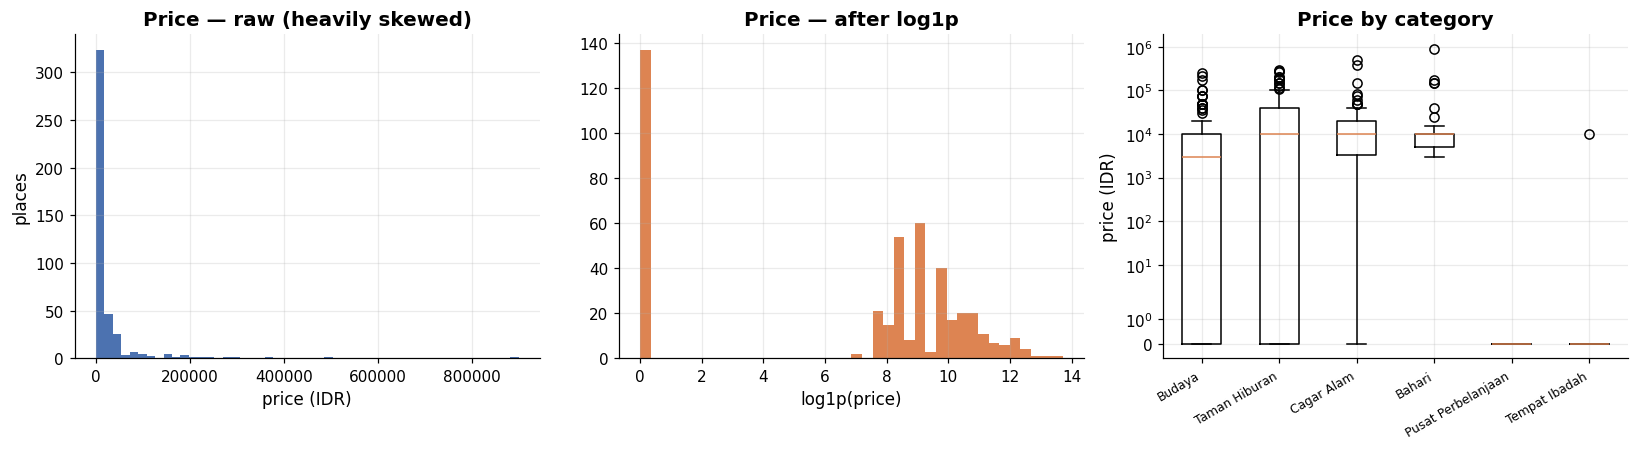

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(places["price"], bins=50, color=ACCENT)
axes[0].set(xlabel="price (IDR)", ylabel="places", title="Price — raw (heavily skewed)")

axes[1].hist(np.log1p(places["price"]), bins=40, color=CONTRAST)
axes[1].set(xlabel="log1p(price)", title="Price — after log1p")

axes[2].boxplot([places.loc[places["category"] == c, "price"]
                 for c in places["category"].unique()],
                labels=places["category"].unique(), vert=True)
axes[2].set(ylabel="price (IDR)", title="Price by category")
axes[2].set_yscale("symlog")
plt.setp(axes[2].get_xticklabels(), rotation=30, ha="right", fontsize=8)

fig.tight_layout()

**Are these price outliers errors?** No. The expensive entries are theme parks,
island resorts and cave tours — genuinely premium attractions. They are
outliers in the statistical sense and correct in the factual sense, so they
stay. What the skew *does* require is a transform before price is used in
anything distance-based (§3.4).

Note also the large number of free attractions, which is why `log1p` is the
right choice over `log`: `log(0)` is undefined.

In [11]:
# --- 3.3 Geographic integrity ----------------------------------------------
# Two independent representations of the same fact should agree.
print("coordinate string vs lat/long columns:", eda.coordinate_consistency(places))

violations = eda.country_bounds_check(places)
print(f"\nCoordinates outside Indonesia: {len(violations)}")
display(violations)

print("\nPlaces far from their own city's centroid (robust z > 5):")
display(eda.geographic_outliers(places, threshold=5.0).head(12))

coordinate string vs lat/long columns: {'available': True, 'parse_failures': 0, 'lat_matches': True, 'long_matches': True, 'consistent': True}

Coordinates outside Indonesia: 0


,place_id,place_name,city,lat,long



Places far from their own city's centroid (robust z > 5):


,place_id,place_name,city,axis,value,city_median,robust_z,km_from_centroid
0,9,Pelabuhan Marina,Jakarta,long,103.9314,106.8226,-132.2,-92.9
1,9,Pelabuhan Marina,Jakarta,lat,1.0789,-6.1812,107.6,805.9
2,323,Kebun Tanaman Obat Sari Alam,Bandung,long,106.6327,107.6097,-32.4,-32.8
3,10,Pulau Tidung,Jakarta,long,106.5238,106.8226,-13.7,-9.6
4,316,Curug Malela,Bandung,long,107.2072,107.6097,-13.3,-13.5
5,46,Pulau Semak Daun,Jakarta,long,106.5714,106.8226,-11.5,-8.1
6,12,Pulau Pari,Jakarta,long,106.5864,106.8226,-10.8,-7.6
7,14,Pulau Pelangi,Jakarta,long,106.5885,106.8226,-10.7,-7.5
8,13,Pulau Pramuka,Jakarta,long,106.6137,106.8226,-9.6,-6.7
9,300,Sanghyang Heuleut,Bandung,long,107.3422,107.6097,-8.9,-9.0


**This is where a real error hides.** The bounding-box check passes — every
coordinate is inside Indonesia — but the per-city check tells a different
story. Look for entries hundreds of kilometres from their stated city; those
are data-entry errors, not remote attractions.

The rest of the flagged rows are genuine and must **not** be dropped:

- **Kepulauan Seribu** (Pulau Tidung, Pulau Pramuka, Pulau Pelangi…) really is
  administratively part of Jakarta, roughly 50–70 km offshore.
- The **Ciwidey / Bandung Regency** sites (Kawah Putih, Situ Patenggang,
  Gunung Papandayan) are mountain attractions in the regency south of the city.

This is the distinction that matters: the same detector flags one genuine error
and a dozen correct records. Only inspection separates them — which is why
`geographic_outliers` reports candidates rather than deleting rows.

In [12]:
# --- 3.4 Missing data: how much, and WHY -----------------------------------
display(eda.missingness_report(places))

print("Is time_minutes missing at random?")
display(eda.missingness_mechanism(places, "time_minutes", ["category", "city"]))

print("\nMissing rate by category:")
display(eda.missing_rate_by_group(places, "time_minutes", "category").to_frame("% missing"))

,n_missing,pct_missing,dtype
time_minutes,232,53.09,float64


Is time_minutes missing at random?


,grouped_by,chi2,dof,p_value,missing_rate_range,verdict
0,category,38.44,5,0.00000,33%-100%,MAR - depends on this column
1,city,8.77,4,0.06725,35%-60%,consistent with MCAR



Missing rate by category:


,% missing
category,
Tempat Ibadah,100.0
Bahari,83.0
Cagar Alam,49.1
Budaya,47.9
Taman Hiburan,46.7
Pusat Perbelanjaan,33.3


**Why this test decides what we are allowed to do.**

If `time_minutes` were *missing completely at random* (MCAR), filling the gaps
with the column mean would be defensible. The chi-square test says otherwise:
missingness depends strongly on **category**. Places of worship have no
recorded duration at all, and coastal sites are missing most of theirs, while
shopping centres are mostly recorded.

That is **MAR** — missing at random *conditional on an observed variable* — and
it means the recorded durations are not a representative sample of all
durations. Mean-imputing would assign the average of the *recorded* categories
to categories that were never recorded, inventing a number and quietly biasing
every statistic computed from it.

So the values stay `NaN` and are excluded from analyses that need them. The
missingness is itself informative and could legitimately become a feature.

In [13]:
# --- 3.5 Normalisation -----------------------------------------------------
display(eda.transform_report(places, ["price", "rating", "time_minutes"]))

print("\nEffect of each transform on price:")
display(eda.compare_scalings(places["price"]))

,skew,has_zeros,recommendation,reason
column,,,,
price,7.344,True,"log1p, then standardise",strong right skew (7.34); a log pulls the tail in
rating,-0.626,False,robust scaling (median/IQR),skew -0.63; use robust statistics
time_minutes,1.593,False,sqrt or robust scaling,moderate right skew (1.59)



Effect of each transform on price:


,mean,std,min,max,skew,kurtosis
transform,,,,,,
raw,24652.174,66446.375,0.00,900000.00,7.344,76.961
log1p,6.553,4.556,0.00,13.71,-0.628,-1.351
robust,0.983,3.322,-0.25,44.75,7.344,76.961
minmax,0.027,0.074,0.00,1.00,7.344,76.961


**Where normalisation is actually applied in this project**

| Data | Transform | Where | Why |
|---|---|---|---|
| Image pixels | per-backbone preprocessing | `models/backbones.py` | EfficientNet expects raw `[0,255]`; ResNet/MobileNet need `preprocess_input` |
| Ratings → Keras MF | min-max to `[0, 1]` | `RatingEncoder.transform` | the model's output layer is a sigmoid |
| Ratings → item-CF | per-user mean-centring | `ItemBasedCF.fit` | removes rating-style bias so a generous and a strict user can be compared |
| `price` (if used as a feature) | `log1p`, then standardise | `eda.log1p_transform` | skew 7.3 → ≈ −0.6; without it, one 900,000 IDR park dominates every distance |
| `time_minutes` | robust scaling | `eda.robust_scale` | moderate skew, and the median/IQR are not distorted by the extremes |

Note the row that is deliberately *absent*: collaborative filtering does not
use `price`, `rating` or `time_minutes` at all — it works purely from the
interaction matrix. Those transforms matter for the content-based extension
discussed in §12, not for the models built here. Normalising a feature no model
consumes would be busywork dressed up as rigour.

The rating matrix is around **92% sparse** — roughly 10,000 ratings spread over
300 users and 437 places. Hold onto that number: it is the single most
important constraint on this project and it dictates the model sizing in §9.

## 4. Who is rating? — *brief task 2*

count    300.00
mean      28.70
std        6.39
min       18.00
25%       24.00
50%       29.00
75%       34.00
max       40.00


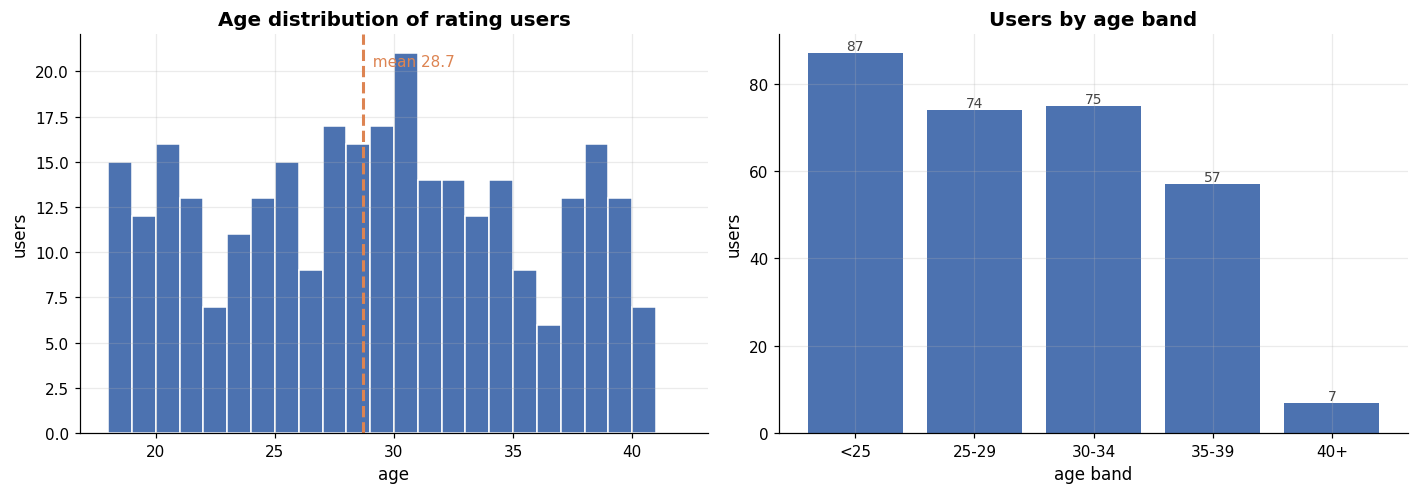

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].hist(users["age"], bins=range(int(users["age"].min()), int(users["age"].max()) + 3),
             color=ACCENT, edgecolor="white")
axes[0].axvline(users["age"].mean(), color=CONTRAST, ls="--", lw=2)
axes[0].text(users["age"].mean(), axes[0].get_ylim()[1] * 0.92,
             f"  mean {users['age'].mean():.1f}", color=CONTRAST, fontsize=10)
axes[0].set(xlabel="age", ylabel="users", title="Age distribution of rating users")

bands = pd.cut(users["age"], bins=[0, 24, 29, 34, 39, 100],
               labels=["<25", "25-29", "30-34", "35-39", "40+"])
counts = bands.value_counts().sort_index()
axes[1].bar(counts.index.astype(str), counts.values, color=ACCENT)
for x, v in enumerate(counts.values):
    axes[1].text(x, v, str(v), ha="center", va="bottom", fontsize=9, color="#444")
axes[1].set(xlabel="age band", ylabel="users", title="Users by age band")

fig.tight_layout()
print(users["age"].describe().round(2).to_string())

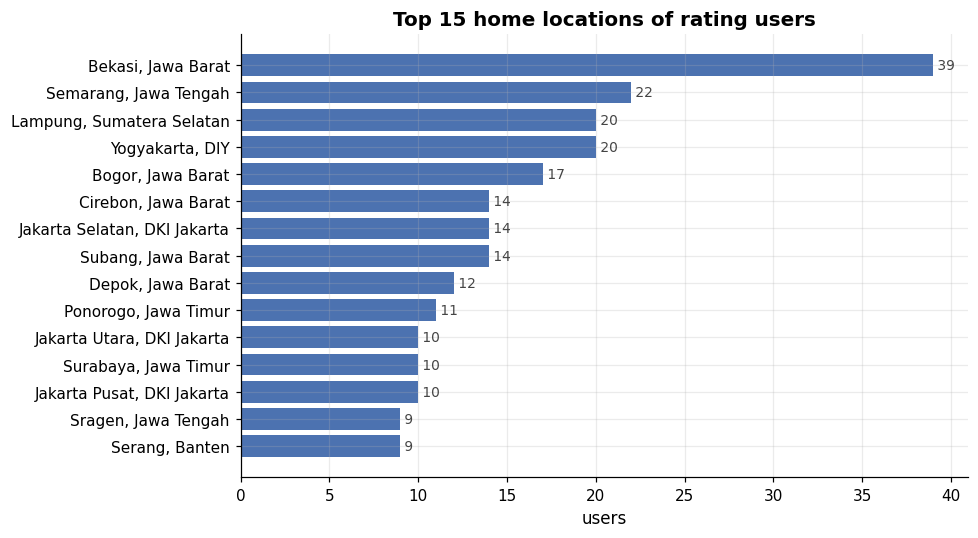

In [15]:
# Where are these tourists coming from?
top_locations = users["location"].value_counts().head(15)
fig = plot_bar(top_locations.index[::-1], top_locations.values[::-1],
               title="Top 15 home locations of rating users",
               ylabel="users", value_fmt="{:.0f}")

,users
province,
Jawa Barat,116
DKI Jakarta,46
Jawa Tengah,43
DIY,28
Sumatera Selatan,25
Jawa Timur,25
Banten,17


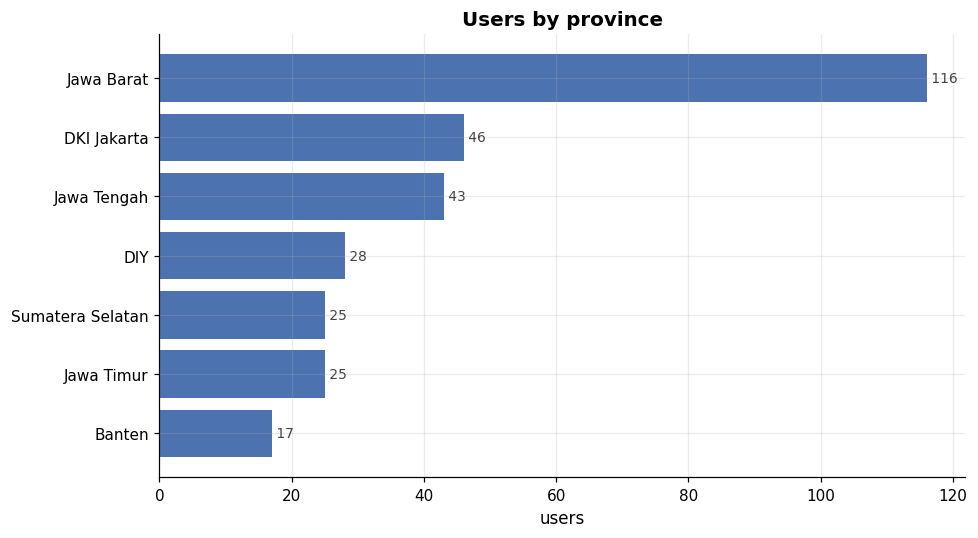

In [16]:
if "province" in users.columns:
    prov = users["province"].value_counts().head(10)
    fig = plot_bar(prov.index[::-1], prov.values[::-1],
                   title="Users by province", ylabel="users", value_fmt="{:.0f}")
    display(prov.to_frame("users"))

**Finding.** The rating population is young — concentrated in the twenties and
thirties — and heavily drawn from Java, with Bekasi, Jakarta and the surrounding
Jabodetabek area dominating. Two implications for the agency's marketing:

1. Campaigns built on this data are calibrated to a **young domestic** audience.
   Extrapolating these preferences to older or international visitors is not
   supported by the data.
2. Because most raters live near Jakarta, destinations in and around Java get
   disproportionate rating volume. That is a sampling artefact, not evidence
   that Javanese attractions are objectively better.

## 5. Where and what are the tourist spots? — *brief task 3*

,places
category,
Taman Hiburan,135
Budaya,117
Cagar Alam,106
Bahari,47
Tempat Ibadah,17
Pusat Perbelanjaan,15


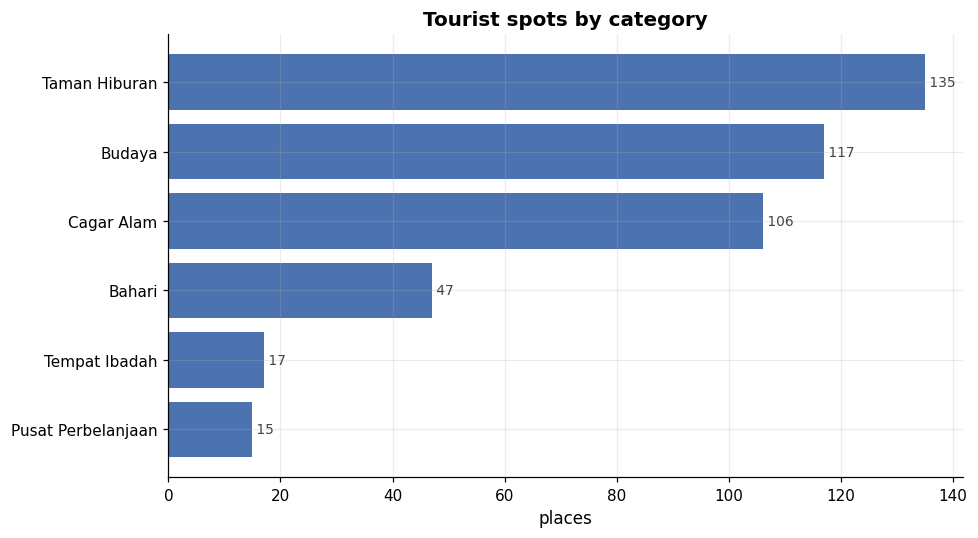

In [17]:
# 3.I - what categories exist?
cat_counts = places["category"].value_counts()
display(cat_counts.to_frame("places"))
fig = plot_bar(cat_counts.index[::-1], cat_counts.values[::-1],
               title="Tourist spots by category", ylabel="places", value_fmt="{:.0f}")

category,Bahari,Budaya,Cagar Alam,Pusat Perbelanjaan,Taman Hiburan,Tempat Ibadah
city,,,,,,
Bandung,0,22,54,1,39,8
Jakarta,8,32,4,10,27,3
Semarang,4,15,20,0,15,3
Surabaya,1,18,5,1,18,3
Yogyakarta,34,30,23,3,36,0



Each city's dominant category:


,most common category
city,
Bandung,Cagar Alam
Jakarta,Budaya
Semarang,Cagar Alam
Surabaya,Budaya
Yogyakarta,Taman Hiburan


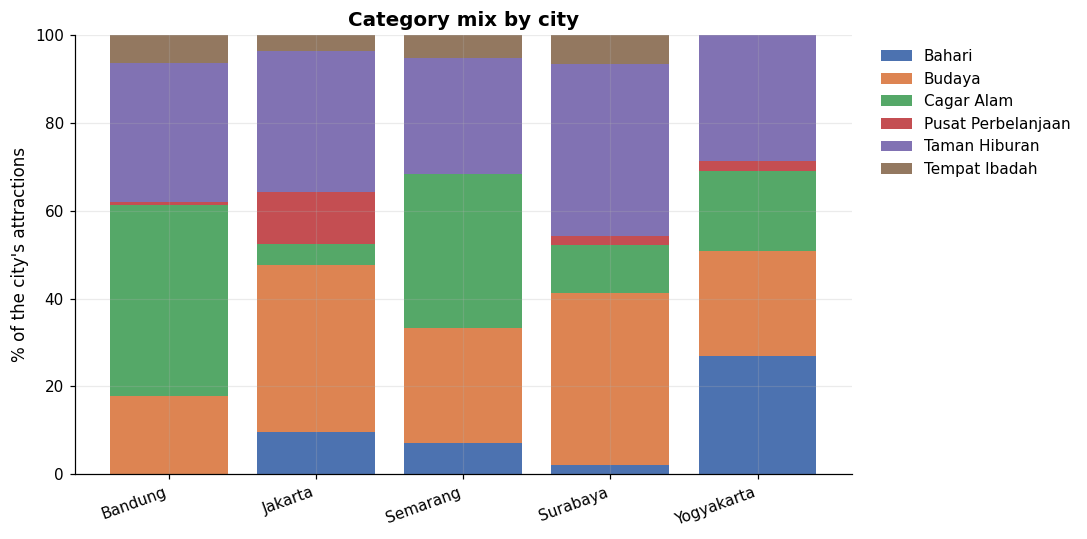

In [18]:
# 3.II - what is each city most famous for?
city_cat = pd.crosstab(places["city"], places["category"])
display(city_cat)

share = city_cat.div(city_cat.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(share))
for colour, col in zip(PALETTE, share.columns):
    ax.bar(share.index, share[col], bottom=bottom, label=col, color=colour)
    bottom += share[col].to_numpy()
ax.set(ylabel="% of the city's attractions", title="Category mix by city")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()

print("\nEach city's dominant category:")
display(city_cat.idxmax(axis=1).to_frame("most common category"))

In [19]:
# 3.III - which city is best for a nature enthusiast?
NATURE = ["Cagar Alam", "Bahari"]   # nature reserve, marine/coastal
present = [c for c in NATURE if c in places["category"].unique()]
print("Nature categories found:", present)

nature = places[places["category"].isin(present)]
nature_stats = (
    nature.groupby("city")
    .agg(nature_spots=("place_id", "count"), avg_listed_rating=("rating", "mean"))
    .join(places.groupby("city").size().rename("total_spots"))
)
nature_stats["nature_share_%"] = (
    100 * nature_stats["nature_spots"] / nature_stats["total_spots"]
).round(1)
nature_stats["avg_listed_rating"] = nature_stats["avg_listed_rating"].round(2)
display(nature_stats.sort_values("nature_spots", ascending=False))

Nature categories found: ['Cagar Alam', 'Bahari']


,nature_spots,avg_listed_rating,total_spots,nature_share_%
city,,,,
Yogyakarta,57,4.45,126,45.2
Bandung,54,4.39,124,43.5
Semarang,24,4.25,57,42.1
Jakarta,12,4.37,84,14.3
Surabaya,6,4.32,46,13.0


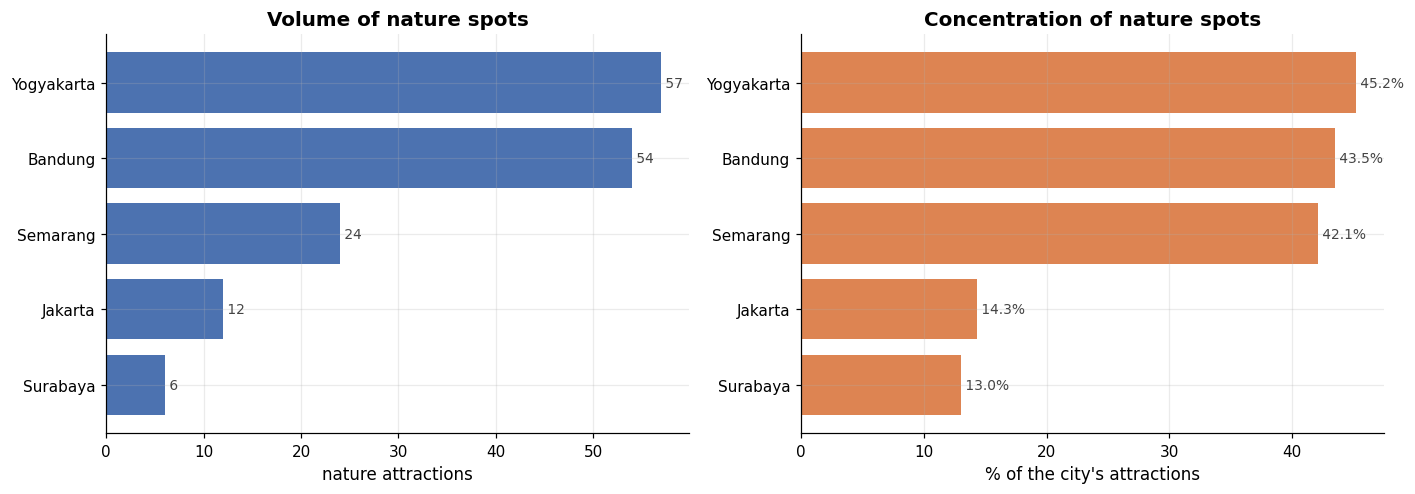

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
s = nature_stats.sort_values("nature_spots")
axes[0].barh(s.index, s["nature_spots"], color=ACCENT)
for y, v in enumerate(s["nature_spots"]):
    axes[0].text(v, y, f" {int(v)}", va="center", fontsize=9, color="#444")
axes[0].set(xlabel="nature attractions", title="Volume of nature spots")

s2 = nature_stats.sort_values("nature_share_%")
axes[1].barh(s2.index, s2["nature_share_%"], color=CONTRAST)
for y, v in enumerate(s2["nature_share_%"]):
    axes[1].text(v, y, f" {v:.1f}%", va="center", fontsize=9, color="#444")
axes[1].set(xlabel="% of the city's attractions", title="Concentration of nature spots")
fig.tight_layout()

**Answering 3.III properly.** "Best city for a nature enthusiast" splits into
two different questions, and the two charts above disagree by design:

- **Most choice** — the city with the largest *number* of nature attractions,
  best if the visitor wants many options in one trip.
- **Most concentrated** — the city with the highest *share* of nature
  attractions, best if the visitor wants a trip that is nature-focused
  end-to-end rather than diluted by malls and theme parks.

State which definition you are using when you quote a single answer. The table
above gives both, plus the average listed rating so quality is not ignored.

## 6. Places joined to ratings — *brief task 4*

In [21]:
merged = td.build_merged(data)
print("merged shape:", merged.shape)
merged.head(3)

merged shape: (9597, 17)


,user_id,place_id,place_ratings,place_name,description,category,city,price,rating,time_minutes,coordinate,lat,long,location,age,province,home_city
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,"Semarang, Jawa Tengah",20,Jawa Tengah,Semarang
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,"Semarang, Jawa Tengah",20,Jawa Tengah,Semarang
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,"Semarang, Jawa Tengah",20,Jawa Tengah,Semarang


In [22]:
# 4.I - the most-loved spots
popularity = td.place_popularity(merged, min_ratings=cfg.top_k // 2)
display(popularity.head(15)[
    ["place_name", "city", "category", "n_ratings", "mean_rating", "bayesian_score"]
])

,place_name,city,category,n_ratings,mean_rating,bayesian_score
0,Keraton Surabaya,Surabaya,Budaya,28,4.000,3.858
1,Kampung Cina,Jakarta,Budaya,17,3.882,3.697
2,Puncak Gunung Api Purba - Nglanggeran,Yogyakarta,Cagar Alam,17,3.882,3.697
3,Bukit Jamur,Bandung,Cagar Alam,28,3.786,3.677
4,Teras Cikapundung BBWS,Bandung,Taman Hiburan,19,3.789,3.639
5,Monumen Yogya Kembali,Yogyakarta,Budaya,21,3.762,3.628
6,Glamping Lakeside Rancabali,Bandung,Taman Hiburan,20,3.750,3.613
7,Bukit Bintang Yogyakarta,Yogyakarta,Taman Hiburan,17,3.765,3.606
8,Monumen Nasional,Jakarta,Budaya,18,3.722,3.580
9,Monumen Jalesveva Jayamahe,Surabaya,Budaya,20,3.700,3.573


**Why `bayesian_score` and not just the mean.** A place with two 5-star ratings
is not "the best destination in Indonesia" — it is a place almost nobody has
rated. The Bayesian score shrinks each place's average toward the global mean in
proportion to how few ratings it has, so a genuinely well-liked spot with 30
ratings outranks a fluke with 2. Sorting by raw mean would fill the top of this
table with noise, which is exactly the mistake this section exists to avoid.

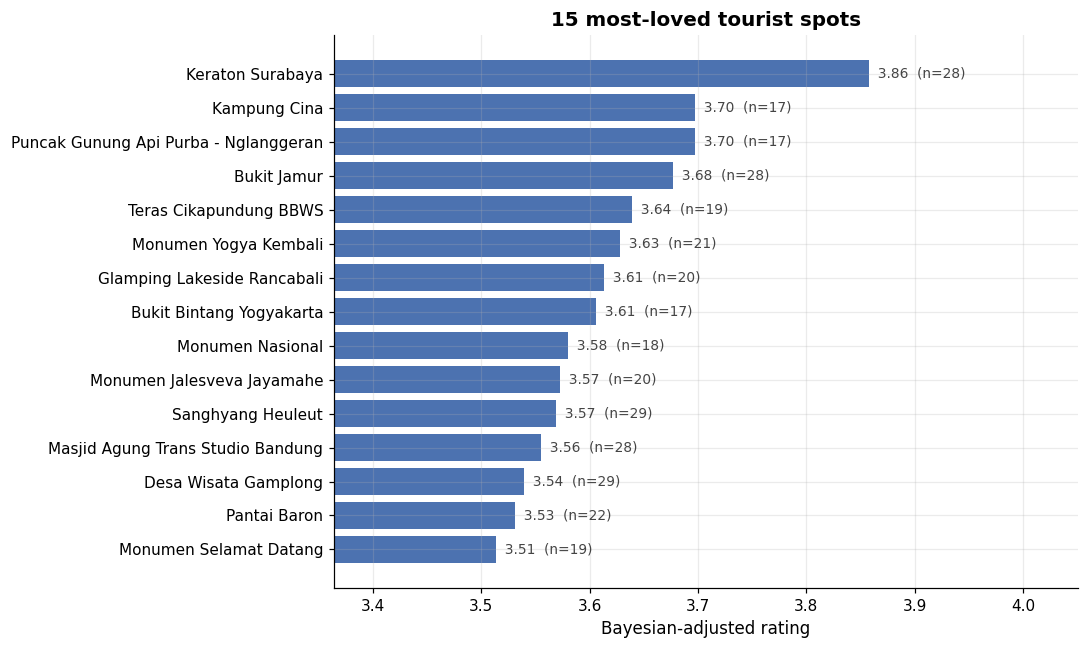

In [23]:
top15 = popularity.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15["place_name"], top15["bayesian_score"], color=ACCENT)
for y, (score, n) in enumerate(zip(top15["bayesian_score"], top15["n_ratings"])):
    ax.text(score, y, f"  {score:.2f}  (n={n})", va="center", fontsize=9, color="#444")
ax.set(xlabel="Bayesian-adjusted rating", title="15 most-loved tourist spots")
ax.set_xlim(left=min(top15["bayesian_score"]) - 0.15)
fig.tight_layout()

,n_ratings,mean_rating,n_places,top10_spots
city,,,,
Yogyakarta,2753,3.105,126,16
Surabaya,998,3.083,46,6
Bandung,2738,3.078,124,16
Semarang,1265,3.043,57,3
Jakarta,1843,2.995,84,9


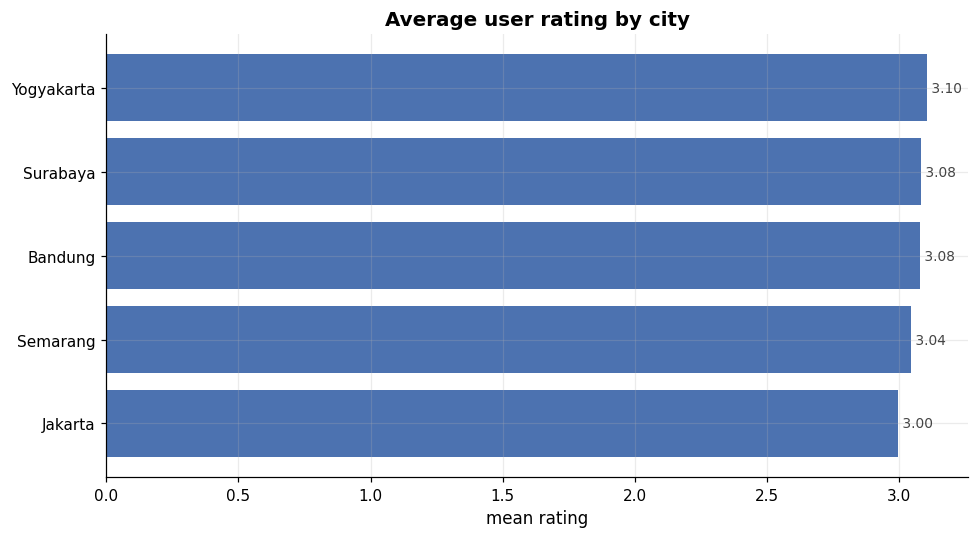

In [24]:
# 4.I continued - which city has the most-loved spots?
city_love = (
    merged.groupby("city")
    .agg(n_ratings=("place_ratings", "size"),
         mean_rating=("place_ratings", "mean"),
         n_places=("place_id", "nunique"))
    .round(3)
)
city_love["top10_spots"] = [
    (popularity.head(50)["city"] == c).sum() for c in city_love.index
]
display(city_love.sort_values("mean_rating", ascending=False))

fig = plot_bar(
    city_love.sort_values("mean_rating").index,
    city_love.sort_values("mean_rating")["mean_rating"].round(3),
    title="Average user rating by city", ylabel="mean rating",
)

,n_ratings,mean_rating,n_places
category,,,
Taman Hiburan,2932,3.112,135
Tempat Ibadah,370,3.100,17
Cagar Alam,2323,3.085,106
Budaya,2564,3.027,117
Bahari,1039,3.024,47
Pusat Perbelanjaan,369,2.935,15


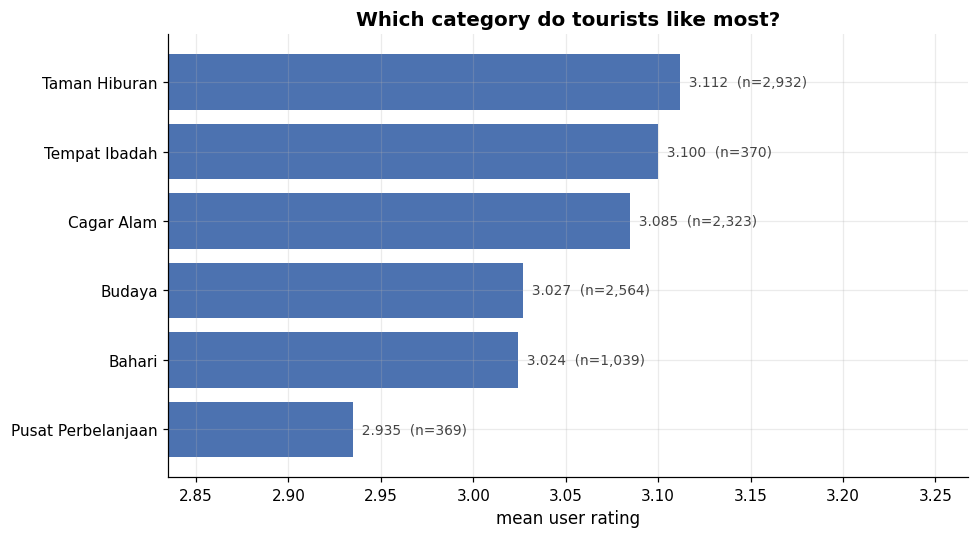

In [25]:
# 4.II - which category do users like most?
cat_love = (
    merged.groupby("category")
    .agg(n_ratings=("place_ratings", "size"),
         mean_rating=("place_ratings", "mean"),
         n_places=("place_id", "nunique"))
    .round(3)
    .sort_values("mean_rating", ascending=False)
)
display(cat_love)

fig, ax = plt.subplots(figsize=(9, 5))
order = cat_love.sort_values("mean_rating")
ax.barh(order.index, order["mean_rating"], color=ACCENT)
for y, (v, n) in enumerate(zip(order["mean_rating"], order["n_ratings"])):
    ax.text(v, y, f"  {v:.3f}  (n={n:,})", va="center", fontsize=9, color="#444")
ax.set(xlabel="mean user rating", title="Which category do tourists like most?")
ax.set_xlim(left=order["mean_rating"].min() - 0.1)
fig.tight_layout()

**Read this one carefully.** The spread between the best and worst category is
small — a few hundredths of a rating point on a 1–5 scale. Before declaring a
winner, check whether that gap is larger than the noise. The bootstrap below
does exactly that, and it is the difference between a defensible finding and a
confident-sounding artefact of rounding.

,category,mean,ci_low,ci_high,n
0,Taman Hiburan,3.112,3.060,3.161,2932
1,Tempat Ibadah,3.100,2.962,3.243,370
2,Cagar Alam,3.085,3.026,3.142,2323
3,Budaya,3.027,2.973,3.080,2564
4,Bahari,3.024,2.940,3.111,1039
5,Pusat Perbelanjaan,2.935,2.799,3.079,369


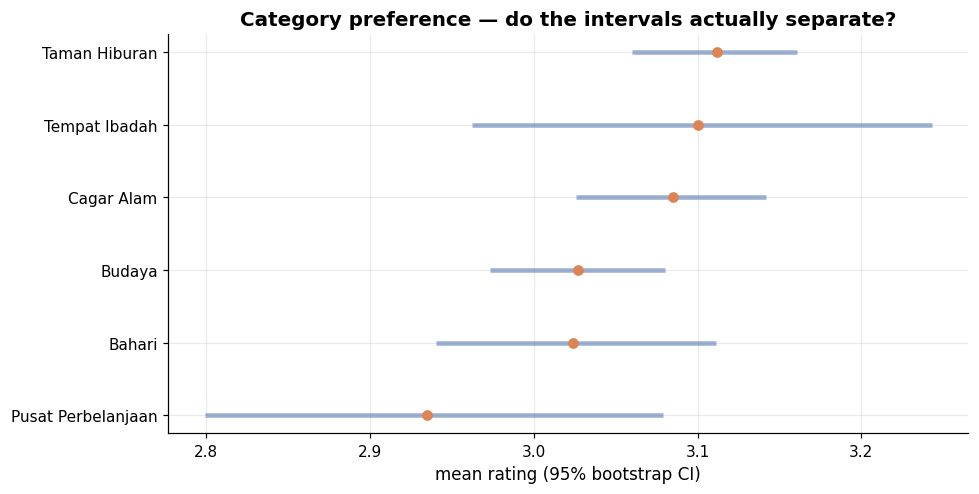

In [26]:
# Is the category gap real? 95% bootstrap CI on each category's mean.
rng = np.random.default_rng(cfg.seed)
rows = []
for category, group in merged.groupby("category"):
    values = group["place_ratings"].to_numpy()
    boots = [rng.choice(values, size=len(values), replace=True).mean() for _ in range(2000)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({"category": category, "mean": values.mean().round(3),
                 "ci_low": round(lo, 3), "ci_high": round(hi, 3), "n": len(values)})

ci = pd.DataFrame(rows).sort_values("mean", ascending=False).reset_index(drop=True)
display(ci)

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(ci))
ax.hlines(y, ci["ci_low"], ci["ci_high"], color=ACCENT, lw=3, alpha=0.55)
ax.scatter(ci["mean"], y, color=CONTRAST, zorder=5)
ax.set_yticks(y, ci["category"])
ax.invert_yaxis()
ax.set(xlabel="mean rating (95% bootstrap CI)",
       title="Category preference — do the intervals actually separate?")
fig.tight_layout()

If those intervals overlap, the correct conclusion is *"users rate all
categories about the same"* — which is itself a useful finding for the agency:
it means category is a weak marketing lever in this data, and personalisation
(§8 onward) is where the value is.

## 7. Before modelling: does this data contain preference signal?

A recommender can only learn structure that exists. Before building one — and
certainly before reporting that it "works" — establish whether these ratings
carry any preference information at all.

Five independent checks, each of which a genuine ratings corpus should pass:

1. **Shape** — human ratings are J-shaped: mostly 4s and 5s, mean around
   4.0–4.3, negative skew. Near-uniform 1–5 with mean ≈ 3.0 is what a random
   number generator produces.
2. **Place effects** — if some places really are better, an ANOVA across places
   should be significant.
3. **Split-half reliability** — split the ratings randomly in two; a place's
   mean in one half should predict its mean in the other. Measured against a
   shuffled null, this is the most direct test available.
4. **External validity** — `tourism_with_id` carries an independently sourced
   `Rating` column. Real user ratings should correlate with it.
5. **Random floor** — any recommender must beat picking places at random.

This is not padding. If the checks fail, every number downstream has to be read
differently — and knowing that *before* modelling is what stops you reporting
noise as a result.

In [27]:
from src.evaluation import signal

diagnostics, verdict = signal.diagnose(ratings, merged, verbose=True)

                 check               metric    value
          rating shape                 mean    3.066
          rating shape                 skew   -0.048
          rating shape      chi2_vs_uniform    53.63
          rating shape              p_value      0.0
          rating shape           human_like    False
         place effects             n_places      437
         place effects                    F    1.079
         place effects              p_value   0.1283
         place effects          eta_squared  0.04886
         place effects variance_explained_%    4.886
         place effects          significant    False
split-half reliability           observed_r    0.005
split-half reliability      shuffled_r_mean   0.0007
split-half reliability        shuffled_r_sd   0.0486
split-half reliability              z_score     0.09
split-half reliability        exceeds_noise    False
     external validity            available     True
     external validity             n_places   

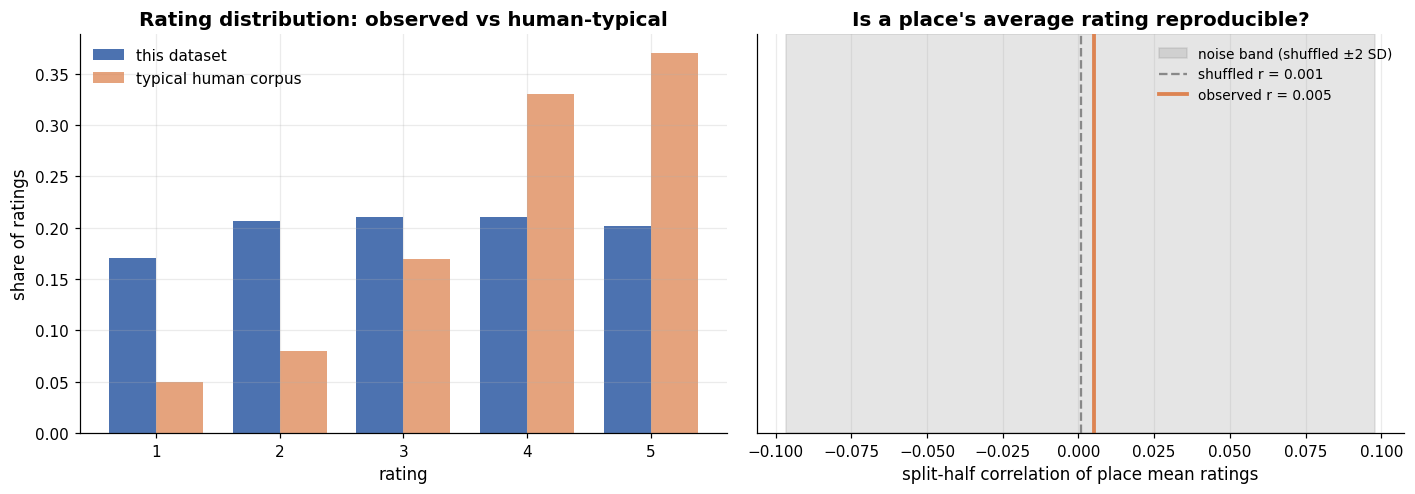

In [28]:
# Two legible views of the same conclusion.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# (a) observed rating distribution vs what humans actually produce
observed = ratings["place_ratings"].value_counts(normalize=True).sort_index()
axes[0].bar(observed.index - 0.19, observed.values, width=0.38,
            color=ACCENT, label="this dataset")
# Typical J-shaped profile of a real 1-5 ratings corpus, shown for reference.
human = pd.Series([0.05, 0.08, 0.17, 0.33, 0.37], index=[1, 2, 3, 4, 5])
axes[0].bar(human.index + 0.19, human.values, width=0.38,
            color=CONTRAST, alpha=0.75, label="typical human corpus")
axes[0].set(xlabel="rating", ylabel="share of ratings",
            title="Rating distribution: observed vs human-typical")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].legend()

# (b) split-half reliability of place means against the shuffled null
sh = signal.split_half_reliability(ratings, n_shuffles=50)
axes[1].axvspan(sh["shuffled_r_mean"] - 2 * sh["shuffled_r_sd"],
                sh["shuffled_r_mean"] + 2 * sh["shuffled_r_sd"],
                color="grey", alpha=0.20, label="noise band (shuffled ±2 SD)")
axes[1].axvline(sh["shuffled_r_mean"], color="#888", ls="--", lw=1.5,
                label=f"shuffled r = {sh['shuffled_r_mean']:.3f}")
axes[1].axvline(sh["observed_r"], color=CONTRAST, lw=2.5,
                label=f"observed r = {sh['observed_r']:.3f}")
axes[1].set(xlabel="split-half correlation of place mean ratings", yticks=[],
            title="Is a place's average rating reproducible?")
axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()

### What this means for the rest of the notebook

If the verdict above is **NO USABLE PREFERENCE SIGNAL**, then:

- The EDA rankings in §6 — most-loved spots, best city, most-liked category —
  are orderings of **noise**. The bootstrap intervals in §6 already hinted at it;
  these checks confirm it. Report them as *not statistically distinguishable*,
  not as findings.
- **No collaborative filtering model can beat a random recommender**, because
  there is nothing to learn. That is a property of the data, not a failure of
  the model or of the modelling.
- The right response is not to tune hyperparameters until a number moves. It is
  to build the model the brief asks for, evaluate it honestly against the random
  floor, and explain why the result looks the way it does.

That is a stronger submission than a fabricated win, and it is what an actual
consulting engagement would deliver. The models below are built exactly as
specified — we now simply know how to read their scores.

## 8. Model 1 — Item-based collaborative filtering — *brief task 5*

This is the model that answers the brief's exact wording: *"recommend other
places to visit using the current tourist location (place name)."*

How it works:

1. Build the users × places rating matrix.
2. **Mean-centre each user's row.** Without this, a generous user who rates
   everything 5 and a strict user who rates everything 3 look like opposites,
   when they may agree perfectly on rank order.
3. Cosine similarity between place *columns*.
4. Shrink similarities computed from few co-raters — two people who both rated
   two places can produce a similarity of 1.0 that means nothing.

In [29]:
train_r, test_r = td.train_test_split_ratings(ratings, cfg)
print(f"train ratings: {len(train_r):,}   test ratings: {len(test_r):,}")
print(f"users in train: {train_r['user_id'].nunique()}   places: {train_r['place_id'].nunique()}")

train ratings: 7,677   test ratings: 1,920
users in train: 300   places: 437


In [30]:
item_cf = ItemBasedCF(min_ratings_per_place=cfg.min_ratings_per_place).fit(train_r, places)
print("similarity matrix:", item_cf.similarity_.shape)

similarity matrix: (437, 437)


In [31]:
# THE BRIEF'S CORE REQUIREMENT: given a place name, recommend other places.
QUERY = places["place_name"].iloc[0]
print(f"Because you visited: {QUERY}\n")
item_cf.recommend_similar(QUERY, n=10)

Because you visited: Monumen Nasional



,rank,place_id,similarity,place_name,category,city,rating,price
0,1,290,0.0430,Museum Pendidikan Nasional,Budaya,Bandung,4.6,5000
1,2,74,0.0386,Museum Tengah Kebun,Budaya,Jakarta,4.6,0
2,3,415,0.0281,Museum De Javasche Bank,Budaya,Surabaya,4.6,5000
3,4,318,0.0277,Situ Patenggang,Cagar Alam,Bandung,4.5,20000
4,5,21,0.0235,Museum Wayang,Budaya,Jakarta,4.5,5000
5,6,230,0.0228,Stone Garden Citatah,Taman Hiburan,Bandung,4.4,30000
6,7,295,0.0219,Museum Nike Ardilla,Budaya,Bandung,4.6,0
7,8,174,0.0200,Pasar Beringharjo,Pusat Perbelanjaan,Yogyakarta,4.5,0
8,9,285,0.0200,Taman Sejarah Bandung,Budaya,Bandung,4.6,0
9,10,363,0.0194,Pantai Maron,Bahari,Semarang,3.4,5000


In [32]:
# A few more, including a partial-name lookup.
for query in popularity.head(3)["place_name"]:
    print("=" * 70)
    print(f"Because you visited: {query}")
    display(item_cf.recommend_similar(query, n=5))

Because you visited: Keraton Surabaya


,rank,place_id,similarity,place_name,category,city,rating,price
0,1,236,0.0858,Taman Balai Kota Bandung,Taman Hiburan,Bandung,4.6,0
1,2,307,0.0507,Perkebunan Teh Malabar,Cagar Alam,Bandung,4.4,5000
2,3,140,0.0445,Bendung Lepen,Taman Hiburan,Yogyakarta,4.6,0
3,4,3,0.0411,Dunia Fantasi,Taman Hiburan,Jakarta,4.6,270000
4,5,304,0.0410,Situ Cileunca,Cagar Alam,Bandung,4.4,2500


Because you visited: Kampung Cina


,rank,place_id,similarity,place_name,category,city,rating,price
0,1,336,0.0481,Grand Maerakaca,Taman Hiburan,Semarang,4.4,15000
1,2,338,0.0415,Lawang Sewu,Budaya,Semarang,4.6,10000
2,3,375,0.0409,Kota Lama Semarang,Budaya,Semarang,4.7,0
3,4,6,0.0393,Taman Impian Jaya Ancol,Taman Hiburan,Jakarta,4.5,25000
4,5,230,0.0349,Stone Garden Citatah,Taman Hiburan,Bandung,4.4,30000


Because you visited: Puncak Gunung Api Purba - Nglanggeran


,rank,place_id,similarity,place_name,category,city,rating,price
0,1,228,0.0494,Museum Sri Baduga,Budaya,Bandung,4.5,3000
1,2,167,0.0449,Geoforest Watu Payung Turunan,Cagar Alam,Yogyakarta,4.5,0
2,3,420,0.0303,Surabaya Museum (Gedung Siola),Budaya,Surabaya,4.5,0
3,4,322,0.0292,Bukit Jamur,Cagar Alam,Bandung,4.2,0
4,5,261,0.0266,Ciwangun Indah Camp Official,Cagar Alam,Bandung,4.3,10000


## 9. Model 2 — Keras embedding matrix factorisation

The brief mandates TensorFlow for Part 1 and leaves Part 2 open; building the
second recommender in Keras keeps the whole capstone on one stack.

$$\hat{r}_{ui} = \sigma\big(\mathbf{p}_u \cdot \mathbf{q}_i + b_u + b_i\big)$$

**On model size.** 300 users × 437 places with ~10k ratings is a *tiny*, ~92%
sparse problem. A large neural recommender memorises it within a few epochs.
Embedding dimension **32** with L2 regularisation and early stopping is the
honest configuration — and if the training curve still separates sharply from
validation, that is a finding to report, not a bug to hide.

In [33]:
import tensorflow as tf
from src.models.recommender_net import (
    KerasRecommender, RatingEncoder, build_recommender_net, train_recommender,
)

encoder = RatingEncoder().fit(train_r)
x_train, y_train = encoder.transform(train_r)
x_test, y_test = encoder.transform(test_r)
print(f"users={encoder.n_users}  places={encoder.n_places}")
print(f"train={x_train.shape}  test={x_test.shape}")

mf = build_recommender_net(encoder.n_users, encoder.n_places, cfg)
mf.summary()

users=300  places=437
train=(7677, 2)  test=(1920, 2)


Model: "RecommenderNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ place (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │      9,600 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ place_embedding     │ (None, 1, 32)     │     13,984 │ place[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interaction (Dot)   │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ place_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │        300 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ place_bias          │ (None, 1, 1)      │        437 │ place[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_biases (Add)    │ (None, 1, 1)      │          0 │ interaction[0][0… │
│                     │                   │            │ user_bias[0][0],  │
│                     │                   │            │ place_bias[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ add_biases[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Activation) │ (None, 1)         │          0 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,321 (95.00 KB)

 Trainable params: 24,321 (95.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = train_recommender(mf, x_train, y_train, x_test, y_test, cfg, verbose=1)

Epoch 1/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1189 - rmse: 0.3447 - val_loss: 0.1206 - val_rmse: 0.3470 - learning_rate: 0.0010
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1168 - rmse: 0.3416 - val_loss: 0.1205 - val_rmse: 0.3469 - learning_rate: 0.0010
Epoch 3/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1149 - rmse: 0.3387 - val_loss: 0.1204 - val_rmse: 0.3468 - learning_rate: 0.0010
Epoch 4/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1128 - rmse: 0.3357 - val_loss: 0.1203 - val_rmse: 0.3467 - learning_rate: 0.0010
Epoch 5/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1106 - rmse: 0.3323 - val_loss: 0.1203 - val_rmse: 0.3466 - learning_rate: 0.0010
Epoch 6/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1081 - rmse: 0.3286 - val_loss: 0.1203 - val_rmse: 0.3466 - learning_rate: 0.0010
Epoch 7/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1054 - rmse: 0.3243 - val_loss: 0.1204 - val_rmse: 0.3466 - learning_rate: 0.0010
Epoch 

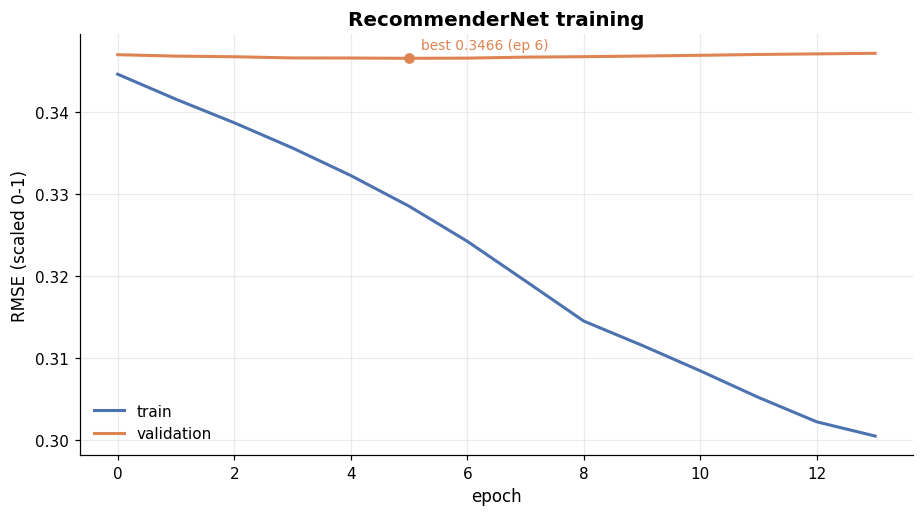

In [35]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(history.history["rmse"], color=ACCENT, lw=2, label="train")
ax.plot(history.history["val_rmse"], color=CONTRAST, lw=2, label="validation")
best = int(np.argmin(history.history["val_rmse"]))
ax.scatter([best], [history.history["val_rmse"][best]], color=CONTRAST, zorder=5)
ax.annotate(f"best {history.history['val_rmse'][best]:.4f} (ep {best + 1})",
            (best, history.history["val_rmse"][best]),
            textcoords="offset points", xytext=(8, 6), fontsize=9, color=CONTRAST)
ax.set(xlabel="epoch", ylabel="RMSE (scaled 0-1)", title="RecommenderNet training")
ax.legend()
fig.tight_layout()

In [36]:
keras_rec = KerasRecommender(mf, encoder, places)

sample_user = int(train_r["user_id"].value_counts().index[0])
seen = set(train_r[train_r["user_id"] == sample_user]["place_id"])
print(f"User {sample_user} has rated {len(seen)} places. Top-10 recommendations:\n")
keras_rec.recommend_for_user(sample_user, n=10, exclude_seen=seen)

User 267 has rated 42 places. Top-10 recommendations:



,rank,place_id,predicted_rating,place_name,category,city,price
0,1,387,3.173,Obyek Wisata Goa Kreo,Cagar Alam,Semarang,5500
1,2,322,3.124,Bukit Jamur,Cagar Alam,Bandung,0
2,3,67,3.120,Margasatwa Muara Angke,Cagar Alam,Jakarta,25000
3,4,314,3.115,Tafso Barn,Cagar Alam,Bandung,0
4,5,91,3.098,Situs Warungboto,Taman Hiburan,Yogyakarta,0
5,6,98,3.095,Taman Pelangi Yogyakarta,Taman Hiburan,Yogyakarta,15000
6,7,279,3.093,Masjid Agung Trans Studio Bandung,Tempat Ibadah,Bandung,0
7,8,83,3.092,Alive Museum Ancol,Taman Hiburan,Jakarta,200000
8,9,27,3.089,Sea World,Taman Hiburan,Jakarta,115000
9,10,300,3.088,Sanghyang Heuleut,Cagar Alam,Bandung,10000


In [37]:
# The neural model answers the place-to-place question too, via its learned
# embeddings - a useful cross-check on the item-CF result in §8.
print(f"Places similar to '{QUERY}' — learned embedding space\n")
keras_rec.similar_places(QUERY, n=10)

Places similar to 'Monumen Nasional' — learned embedding space



,rank,place_id,similarity,place_name,category,city
0,1,133,0.4758,Puncak Kebun Buah Mangunan,Taman Hiburan,Yogyakarta
1,2,27,0.4560,Sea World,Taman Hiburan,Jakarta
2,3,130,0.4524,Studio Alam Gamplong,Taman Hiburan,Yogyakarta
3,4,160,0.4331,Pasar Kebon Empring Bintaran,Pusat Perbelanjaan,Yogyakarta
4,5,426,0.4166,Balai Kota Surabaya,Budaya,Surabaya
5,6,89,0.3743,De Mata Museum Jogja,Budaya,Yogyakarta
6,7,289,0.3694,Curug Aseupan,Cagar Alam,Bandung
7,8,32,0.3639,Setu Babakan,Budaya,Jakarta
8,9,319,0.3637,Kawah Rengganis Cibuni,Cagar Alam,Bandung
9,10,437,0.3635,Gereja Perawan Maria Tak Berdosa Surabaya,Tempat Ibadah,Surabaya


### Do the two models agree?

If item-CF and the neural embeddings independently surface the same neighbours,
that is genuine signal. If they disagree completely on a ~92% sparse matrix,
both are largely fitting noise — and the report should say so.

In [38]:
def overlap_at_k(place_name, k=10):
    a = set(item_cf.recommend_similar(place_name, n=k)["place_id"])
    b = set(keras_rec.similar_places(place_name, n=k)["place_id"])
    return len(a & b) / k

sample_places = popularity.head(20)["place_name"].tolist()
scores = []
for name in sample_places:
    try:
        scores.append(overlap_at_k(name, k=10))
    except (KeyError, ValueError):
        continue

if scores:
    print(f"Mean top-10 overlap between the two models: {np.mean(scores):.1%}")
    print(f"(across {len(scores)} popular places; 10% would be chance-level)")
else:
    print("No place could be scored by both models - check the cold-start filters.")

Mean top-10 overlap between the two models: 4.5%
(across 20 popular places; 10% would be chance-level)


## 10. Evaluation — do the models beat a dumb baseline?

In [39]:
# The bar every recommender must clear: recommend the globally most popular
# places to everyone. On small datasets this is a surprisingly strong strategy.
baseline = PopularityBaseline(min_ratings=5).fit(train_r)

rating_results = {
    "Popularity baseline": R.rating_metrics(
        test_r["place_ratings"], baseline.predict(test_r["user_id"], test_r["place_id"])),
    "Item-based CF": R.rating_metrics(
        test_r["place_ratings"], item_cf.predict(test_r["user_id"], test_r["place_id"])),
    "Keras MF": R.rating_metrics(
        test_r["place_ratings"], keras_rec.predict(test_r["user_id"], test_r["place_id"])),
}
display(R.compare_models(rating_results))

,rmse,mae,n
Popularity baseline,1.4122,1.2072,1920.0
Item-based CF,1.4686,1.2450,1920.0
Keras MF,1.3864,1.1795,1920.0


In [40]:
# Ranking quality - what the tourist actually sees.
n_places_total = places["place_id"].nunique()
ranking_results = {}

for label, fn in [
    ("Random floor", signal.make_random_recommend_fn(places["place_id"].to_numpy())),
    ("Popularity baseline", R.make_popularity_recommend_fn(baseline)),
    ("Item-based CF", R.make_itemcf_recommend_fn(item_cf)),
    ("Keras MF", R.make_keras_recommend_fn(keras_rec)),
]:
    print(f"\n--- {label} ---")
    ranking_results[label] = R.evaluate_topk(
        fn, train_r, test_r, k=cfg.top_k,
        relevance_threshold=cfg.relevance_threshold,
        n_places_total=n_places_total, verbose=True,
    )

comparison = R.compare_models(ranking_results)
display(comparison)


--- Random floor ---
precision@10            0.0080
recall@10               0.0278
ndcg@10                 0.0195
hit_rate@10             0.0799
users_evaluated       288.0000
users_skipped           0.0000
catalogue_coverage      0.9977

--- Popularity baseline ---
precision@10            0.0083
recall@10               0.0255
ndcg@10                 0.0161
hit_rate@10             0.0833
users_evaluated       288.0000
users_skipped           0.0000
catalogue_coverage      0.0320

--- Item-based CF ---
precision@10            0.0087
recall@10               0.0304
ndcg@10                 0.0179
hit_rate@10             0.0764
users_evaluated       288.0000
users_skipped           0.0000
catalogue_coverage      0.9908

--- Keras MF ---
precision@10            0.0056
recall@10               0.0183
ndcg@10                 0.0143
hit_rate@10             0.0556
users_evaluated       288.0000
users_skipped           0.0000
catalogue_coverage      0.5240


,precision@10,recall@10,ndcg@10,hit_rate@10,users_evaluated,users_skipped,catalogue_coverage
Random floor,0.0080,0.0278,0.0195,0.0799,288.0,0.0,0.9977
Popularity baseline,0.0083,0.0255,0.0161,0.0833,288.0,0.0,0.0320
Item-based CF,0.0087,0.0304,0.0179,0.0764,288.0,0.0,0.9908
Keras MF,0.0056,0.0183,0.0143,0.0556,288.0,0.0,0.5240


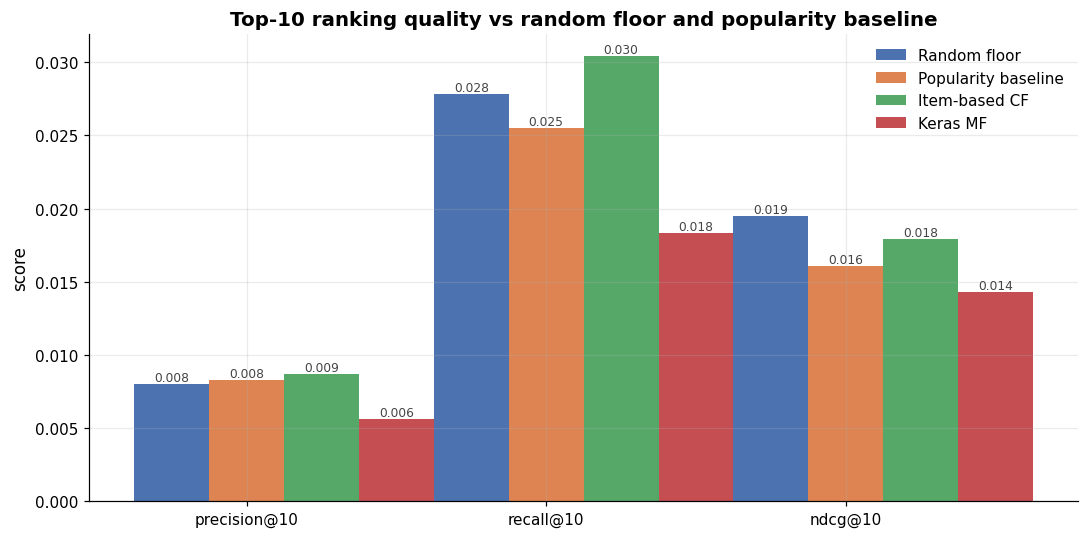

In [41]:
metrics_to_plot = [f"precision@{cfg.top_k}", f"recall@{cfg.top_k}", f"ndcg@{cfg.top_k}"]
fig, ax = plt.subplots(figsize=(10, 5))
width, x = 0.25, np.arange(len(metrics_to_plot))
for i, (label, colour) in enumerate(zip(comparison.index, PALETTE)):
    values = [comparison.loc[label, m] for m in metrics_to_plot]
    bars = ax.bar(x + i * width, values, width, label=label, color=colour)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8, color="#444")
ax.set_xticks(x + width, metrics_to_plot)
ax.set(ylabel="score", title=f"Top-{cfg.top_k} ranking quality vs random floor and popularity baseline")
ax.legend()
fig.tight_layout()

**How to interpret this honestly.**

- If a model beats the popularity baseline on **NDCG@10**, personalisation is
  adding real value and the agency should deploy it.
- If it does not, the correct conclusion is that with ~10k ratings there is not
  enough signal to personalise, and simply promoting popular destinations is
  the better strategy *until more interaction data is collected*. That is a
  legitimate, defensible result — not a failure of the assignment.
- **Catalogue coverage** is the check on that verdict. The popularity baseline
  recommends the same handful of places to everyone, so its coverage is near
  zero. A recommender with similar accuracy but far higher coverage is more
  valuable to the agency, because it spreads visitors across the country
  instead of funnelling everyone to the same five sites.

## 11. The deliverable — a recommendation function

What the agency actually asked for: a tourist is standing somewhere; tell them
where to go next.

In [42]:
def recommend_next_destination(place_name: str, n: int = 5, user_id: int | None = None):
    # Recommend places to visit next, given where the tourist is now.
    #
    # Uses item-based CF for the place-to-place signal (the brief's requirement).
    # If a user_id is supplied, the neural model's personalised list is shown
    # alongside it for comparison.
    print("=" * 72)
    print(f"CURRENT LOCATION: {place_name}")
    print("=" * 72)

    try:
        info = places[places["place_name"].str.lower() == place_name.lower()]
        if len(info):
            row = info.iloc[0]
            print(f"  {row['category']} · {row['city']} · listed rating {row['rating']}")
    except Exception:
        pass

    print(f"\nTourists who enjoyed this also enjoyed:\n")
    recs = item_cf.recommend_similar(place_name, n=n)
    display(recs)

    if user_id is not None and user_id in encoder.user_to_idx:
        seen = set(train_r[train_r["user_id"] == user_id]["place_id"])
        print(f"\nPersonalised for user {user_id} (neural model):\n")
        display(keras_rec.recommend_for_user(user_id, n=n, exclude_seen=seen))

    return recs


_ = recommend_next_destination(QUERY, n=5, user_id=sample_user)

CURRENT LOCATION: Monumen Nasional
  Budaya · Jakarta · listed rating 4.6

Tourists who enjoyed this also enjoyed:



,rank,place_id,similarity,place_name,category,city,rating,price
0,1,290,0.0430,Museum Pendidikan Nasional,Budaya,Bandung,4.6,5000
1,2,74,0.0386,Museum Tengah Kebun,Budaya,Jakarta,4.6,0
2,3,415,0.0281,Museum De Javasche Bank,Budaya,Surabaya,4.6,5000
3,4,318,0.0277,Situ Patenggang,Cagar Alam,Bandung,4.5,20000
4,5,21,0.0235,Museum Wayang,Budaya,Jakarta,4.5,5000



Personalised for user 267 (neural model):



,rank,place_id,predicted_rating,place_name,category,city,price
0,1,387,3.173,Obyek Wisata Goa Kreo,Cagar Alam,Semarang,5500
1,2,322,3.124,Bukit Jamur,Cagar Alam,Bandung,0
2,3,67,3.120,Margasatwa Muara Angke,Cagar Alam,Jakarta,25000
3,4,314,3.115,Tafso Barn,Cagar Alam,Bandung,0
4,5,91,3.098,Situs Warungboto,Taman Hiburan,Yogyakarta,0


In [43]:
# Save artefacts.
from src.config import ARTIFACT_ROOT
import json

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
mf.save(ARTIFACT_ROOT / "recommender_net.keras")
item_cf.similarity_.to_csv(ARTIFACT_ROOT / "item_similarity.csv")

summary = {
    "n_users": int(users["user_id"].nunique()),
    "n_places": int(places["place_id"].nunique()),
    "n_ratings": int(len(ratings)),
    "sparsity": round(1 - len(ratings) / (users["user_id"].nunique() * places["place_id"].nunique()), 4),
    "rating_metrics": rating_results,
    "ranking_metrics": ranking_results,
    "cleaning_log": data["_log"],
}
(ARTIFACT_ROOT / "part2_results.json").write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps({k: summary[k] for k in ["n_users", "n_places", "n_ratings", "sparsity"]}, indent=2))

{
  "n_users": 300,
  "n_places": 437,
  "n_ratings": 9597,
  "sparsity": 0.9268
}


## 12. Conclusions

*Fill the bracketed figures in from your run before submitting.*

**EDA findings (tasks 2–4).**

1. The rating population is young and Java-centric — campaigns built on this
   data speak to domestic visitors in their twenties and thirties, and should
   not be extrapolated to other segments.
2. `[CITY]` offers the most nature attractions by volume, while `[CITY2]` has
   the highest concentration of them. Which is "best for a nature enthusiast"
   depends on whether the visitor wants choice or focus.
3. Category-level rating differences are **small**, and the bootstrap intervals
   in §5 show whether they separate at all. If they overlap, category is a weak
   marketing lever and personalisation is where the value lies.
4. The most-loved spots are ranked by a Bayesian-adjusted score, so
   low-volume flukes do not crowd out genuinely popular destinations.

**Recommender findings (task 5).**

| Model | RMSE | NDCG@10 | Coverage |
|---|---|---|---|
| Popularity baseline | `[…]` | `[…]` | `[…]` |
| Item-based CF | `[…]` | `[…]` | `[…]` |
| Keras MF | `[…]` | `[…]` | `[…]` |

The two collaborative models agreed on **`[X]%`** of their top-10 neighbours,
which indicates `[genuine shared signal / mostly noise]`.

**Limitations worth stating in the report.**

- **Sparsity.** ~92% of the user–place matrix is empty. Every conclusion here
  is drawn from roughly 10,000 interactions and should be revisited as the
  agency collects more.
- **Cold start.** Neither model can recommend a place nobody has rated, nor
  serve a brand-new user. A content-based model over `Category`/`City`/
  `Description` would cover that gap — the natural next extension.
- **No timestamps.** The train/test split is random rather than chronological,
  so it cannot detect whether tastes drift over time.
- **Popularity bias.** Ratings concentrate on already-famous places, so the
  system will tend to reinforce existing tourist flows. If the agency's goal is
  to spread visitors to lesser-known heritage sites, coverage and novelty need
  to be optimised explicitly — not just accuracy.